In [9]:
import numpy as np
import rasterio
import geopandas as gpd
from matplotlib import pyplot as plt
import pandas as pd
from rapidfuzz import process, fuzz
import re
from rasterio.mask import mask
from shapely.geometry import mapping

In [5]:
with rasterio.open('output_hh.tif') as src:
    print(src.width, src.height)
    print(src.crs)

10296 6075
EPSG:4326


In [8]:
gdf = gpd.read_file("/Users/rearustagi/Downloads/03_DISTRICT/DISTRICT.shp")
gdf.head(3)

,OBJECTID,STATE_CODE,DISTRICT,GaPa_NaPa,Type_GN,Province,Area,Shape_Leng,Shape_Area,geometry
0,1,7,DOTI,Adharsha,Gaunpalika,Sudur Pashchim,0.0,282908.088904,2.054599e+09,"POLYGON ((81.03282 29.1862, 81.03295 29.18651,..."
1,2,3,RAMECHHAP,Doramba,Gaunpalika,Bagmati,0.0,295289.035440,1.565522e+09,"POLYGON ((86.22432 27.38306, 86.22421 27.38301..."
2,3,5,DANG,Babai,Gaunpalika,5,0.0,352004.991843,3.059781e+09,"POLYGON ((82.7484 27.82304, 82.74881 27.82289,..."


In [10]:
def get_zonal_stats(tif_path: str, gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Calculate mean and max elevation for each district polygon.
    
    Args:
        tif_path: Path to the elevation GeoTIFF file
        gdf: GeoDataFrame with district geometries
    
    Returns:
        GeoDataFrame with added 'elev_mean' and 'elev_max' columns
    """
    results = []

    with rasterio.open(tif_path) as src:
        # Reproject districts to match raster CRS if needed
        if gdf.crs != src.crs:
            gdf = gdf.to_crs(src.crs)

        for idx, row in gdf.iterrows():
            geom = [mapping(row.geometry)]

            try:
                # Mask raster to district boundary
                out_image, _ = mask(src, geom, crop=True, nodata=np.nan, filled=True)
                data = out_image[0].astype(float)

                # Replace nodata values with NaN
                nodata = src.nodata
                if nodata is not None:
                    data[data == nodata] = np.nan

                # Compute stats, ignoring NaN
                elev_mean = np.nanmean(data) if not np.all(np.isnan(data)) else None
                elev_max  = np.nanmax(data)  if not np.all(np.isnan(data)) else None

            except Exception as e:
                print(f"Skipping district at index {idx}: {e}")
                elev_mean, elev_max = None, None

            results.append({"elev_mean": elev_mean, "elev_max": elev_max})

    stats_df = gpd.GeoDataFrame(results, index=gdf.index)
    return gdf.join(stats_df)

In [11]:
# --- Usage ---
result = get_zonal_stats("output_hh.tif", gdf)
print(result[["elev_mean", "elev_max"]].head())

     elev_mean     elev_max
0  1502.189801  3286.547363
1  2079.053268  6804.967285
2   621.401243  2058.496338
3   155.310414  1110.452637
4   750.830417  2381.372314


In [13]:
result.head(3)

,OBJECTID,STATE_CODE,DISTRICT,GaPa_NaPa,Type_GN,Province,Area,Shape_Leng,Shape_Area,geometry,elev_mean,elev_max
0,1,7,DOTI,Adharsha,Gaunpalika,Sudur Pashchim,0.0,282908.088904,2.054599e+09,"POLYGON ((81.03282 29.1862, 81.03295 29.18651,...",1502.189801,3286.547363
1,2,3,RAMECHHAP,Doramba,Gaunpalika,Bagmati,0.0,295289.035440,1.565522e+09,"POLYGON ((86.22432 27.38306, 86.22421 27.38301...",2079.053268,6804.967285
2,3,5,DANG,Babai,Gaunpalika,5,0.0,352004.991843,3.059781e+09,"POLYGON ((82.7484 27.82304, 82.74881 27.82289,...",621.401243,2058.496338


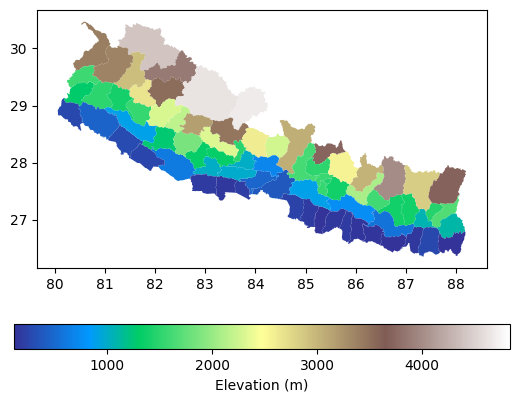

In [21]:
fig = result.plot(
    column="elev_mean",
    cmap="terrain",
    legend=True,
    legend_kwds={"label": "Elevation (m)", "orientation": "horizontal"},
)

In [24]:
print(f"\nSaving merged GeoJSON")
result.to_file("geom_elev.geojson", driver="GeoJSON")
print(f"Done. {len(result):,} features written.")


Saving merged GeoJSON
Done. 77 features written.
